# Week 7 | Feature selection and PCA
**Goal:** inspect pairwise redundancy, fit PCA and report variance honestly.
Attrition is used only to colour the final scatterplot. It never enters PCA.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = next((p if (p/'Source_Code'/'attrition_lab.py').exists() else p/'DSV_PROJECT'
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p/'Source_Code'/'attrition_lab.py').exists() or (p/'DSV_PROJECT'/'Source_Code'/'attrition_lab.py').exists()), None)
if ROOT is None: raise FileNotFoundError('Open this notebook inside DSV_PROJECT')
sys.path.insert(0,str(ROOT/'Source_Code'))
from attrition_lab import load_raw, clean_data, rate_table
raw=load_raw(); clean=clean_data(raw)
pd.set_option('display.max_columns',12)

In [2]:
from advanced_analysis import transform_features,select_correlated,fit_pca
features=transform_features(clean)
selected,decisions,corr=select_correlated(features['matrix'],threshold=.90)
display(decisions)
print('Columns before/after pairwise screen:',features['matrix'].shape[1],selected.shape[1])

,feature,action,reason,paired_with,abs_r
0,Age,keep,passes pairwise screen,,NaN
1,Years at Company,keep,passes pairwise screen,,NaN
2,Monthly Income,keep,passes pairwise screen,,NaN
3,Number of Promotions,keep,passes pairwise screen,,NaN
4,Distance from Home,keep,passes pairwise screen,,NaN
5,Number of Dependents,keep,passes pairwise screen,,NaN
6,Gender_Male,keep,passes pairwise screen,,NaN
7,Job Role_Finance,keep,passes pairwise screen,,NaN
8,Job Role_Healthcare,keep,passes pairwise screen,,NaN
9,Job Role_Media,keep,passes pairwise screen,,NaN


Columns before/after pairwise screen: 40 40


## Selection decision
The threshold is |Pearson r| > 0.90, plus constant-column removal. Later columns are dropped
only when they correlate with an already retained column. In this dataset the screen removes
zero additional columns; we do not invent a removal to satisfy the milestone. Reference-category
dropping already prevents exact within-field dummy redundancy. Pairwise screening does not
prove that all higher-order multicollinearity is absent.

,component,explained_variance_ratio,cumulative_variance_ratio
0,1,0.131152,0.131152
1,2,0.091204,0.222356
2,3,0.085878,0.308234
3,4,0.085359,0.393593
4,5,0.084617,0.478210
5,6,0.039475,0.517685
6,7,0.035375,0.553060
7,8,0.032513,0.585573
8,9,0.029668,0.615240
9,10,0.029073,0.644313


**24 of 40 components** retain **90.10%** of variance.

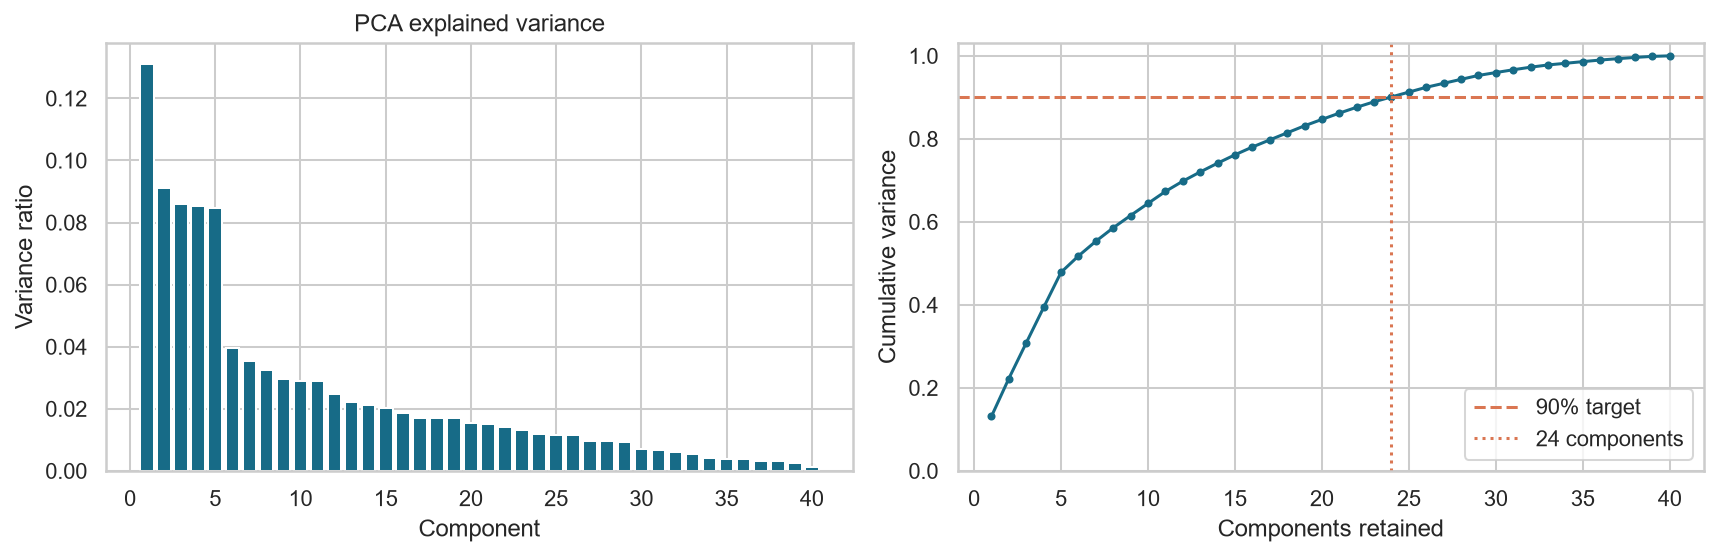

In [3]:
result=fit_pca(selected,.90)
display(result['variance'])
n=result['n_components']
display(Markdown(f"**{n} of {selected.shape[1]} components** retain **{result['retained_variance']:.2%}** of variance."))
display(Image(filename=str(ROOT/'Reports'/'Figures'/'07_explained_variance.png')))

## What does the scatterplot show?
Only the first two components are displayed. We use a fixed sample of 4,000 records to reduce
overplotting; PCA itself uses all 74,498 baseline records. Component signs can flip without
changing the solution. PCA maximizes feature variance, not separation of Left and Stayed.

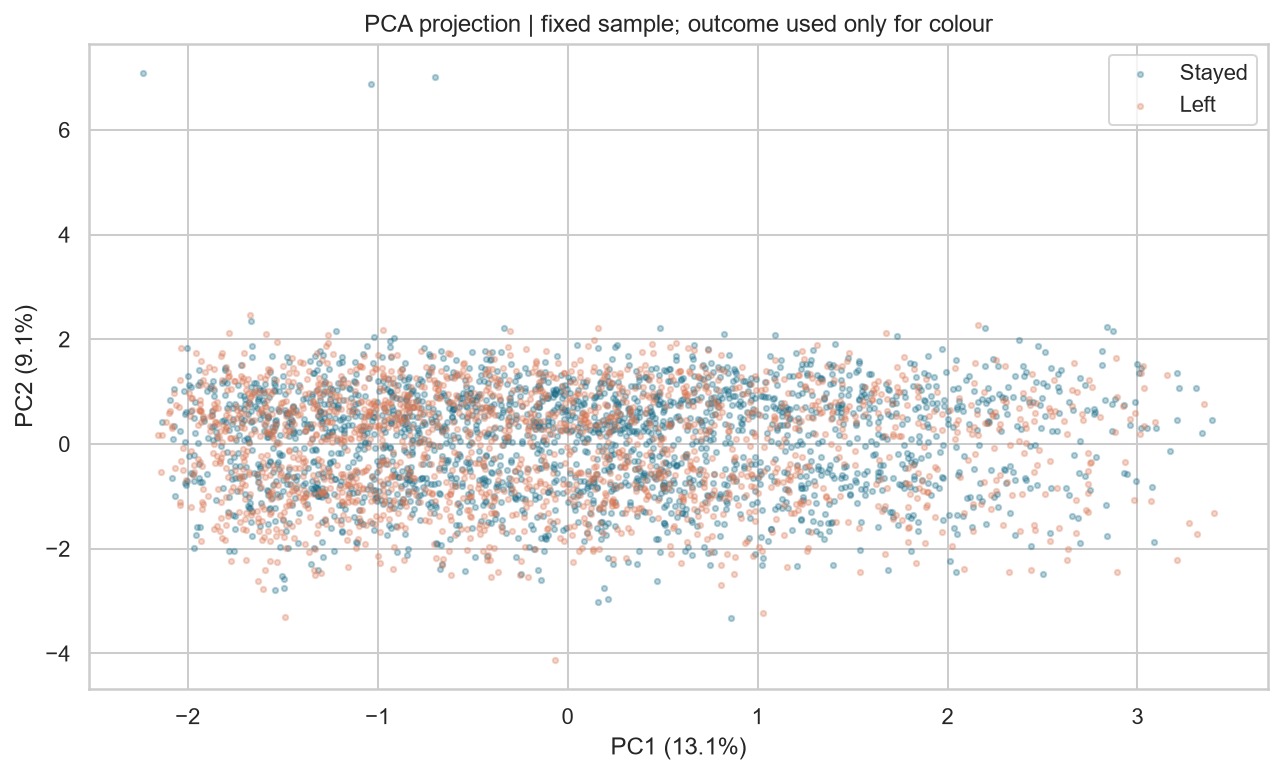

,PC1,PC2
Years at Company,0.706918,0.007495
Age,0.706847,0.013448
Monthly Income,-0.015356,0.960662
Distance from Home,-0.013141,-0.046129
Number of Dependents,0.012265,0.005080
Company Size_Medium,-0.003904,-0.000159
Job Level_Mid,0.003553,-0.003708
Company Size_Small,0.002850,-0.000128


PC1+PC2 retain **22.24%**. Standardizing all dummy columns instead requires **30 components** for 90%, compared with **24** under our primary weighting.

In [4]:
display(Image(filename=str(ROOT/'Reports'/'Figures'/'07_pca_scatter.png')))
display(result['loadings'].loc[result['loadings'].PC1.abs().nlargest(8).index,['PC1','PC2']])
manifest=json.loads((ROOT/'Reports'/'advanced_manifest.json').read_text())
display(Markdown(f"PC1+PC2 retain **{manifest['first_two_variance']:.2%}**. Standardizing all dummy columns instead requires **{manifest['all_columns_standardized_components_90']} components** for 90%, compared with **{n}** under our primary weighting."))

## Peer-review preparation
Ask a teammate to change role and age filters, select an empty cohort, switch PCA between 2D
and 3D, and verify that evidence status is labelled as full-cohort. Automated tests exercise
these paths; human peer review and the expo still need the team to perform them.

[PCA reference](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)